# AI-Native Development Workshop Notebook
> **AI mode:** Overview of AI as chatbot, AI as service, and AI as architecture.

## Building a Local Agentic Workflow with Ollama

This notebook is a **hands-on project** for a 1-hour workshop on **AI-native development**.

You will build a small **AI Lab Assistant** that uses a local LLM through **Ollama** and coordinates three agent-like roles:

1. **Planner** — extracts requirements, proposes a project structure, and creates a plan  
2. **Builder** — generates starter implementation code  
3. **Reviewer** — reviews the generated output and suggests improvements

The objective is to demonstrate the shift from:

> **AI as chatbot → AI as service → AI as architecture**

This notebook is intentionally lightweight and can run locally with a containerized Ollama setup.

## 0. Workshop architecture

> **AI mode:** Architecture overview covering all three modes.

```text
Student / Participant
        ↓
Jupyter Notebook
        ↓
Workflow Coordinator
        ↓
Planner Agent → Builder Agent → Reviewer Agent
        ↓
Ollama Local LLM API
        ↓
Local open model
```

In this workshop, the notebook acts as both the **learning environment** and the **prototype application shell**. Ollama acts as the local model runtime.

## 1. Requirements

> **AI mode:** Setup support for all modes.

Before running the notebook, you need:

- Python 3.10+
- Jupyter Notebook or JupyterLab
- Docker Desktop or Docker Engine
- Ollama running in Docker
- A local model pulled into Ollama, for example `llama3.1`, `llama3`, `mistral`, or `qwen2.5`

### Start Ollama with Docker

CPU-only:

```bash
docker run -d   --name ollama   -p 11434:11434   -v ollama:/root/.ollama   --restart unless-stopped   ollama/ollama
```

NVIDIA GPU:

```bash
docker run -d   --name ollama   -p 11434:11434   -v ollama:/root/.ollama   --gpus=all   --restart unless-stopped   ollama/ollama
```

Pull a model:

```bash
docker exec -it ollama ollama pull llama3.1
```

Check models:

```bash
docker exec -it ollama ollama list
```

## 2. Install notebook dependencies

> **AI mode:** Setup support for all modes.

The notebook only needs standard Python plus `requests`, `pandas`, and `matplotlib`.

Run this cell if needed.

In [1]:
# AI mode: Setup support for all modes.
# Uncomment if needed:
# !pip install requests pandas matplotlib

## 3. Imports and configuration

> **AI mode:** Setup support for all modes.

Set the model name to the model you pulled in Ollama. Common choices: `llama3.1`, `llama3`, `mistral`, `qwen2.5`.

In [2]:
# AI mode: Setup support for all modes.
import json
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Optional

import requests
import pandas as pd
import matplotlib.pyplot as plt

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL", "http://localhost:11434")
MODEL_NAME = os.getenv("OLLAMA_MODEL", "llama3.1")

print("Ollama URL:", OLLAMA_BASE_URL)
print("Model:", MODEL_NAME)

Ollama URL: http://localhost:11434
Model: llama3.1


## 4. Check Ollama connectivity

> **AI mode:** AI as service.

This cell checks whether the notebook can reach the local Ollama API.

If it fails:

1. Make sure the container is running: `docker ps`
2. Make sure port `11434` is exposed
3. Make sure the model is pulled
4. If using a remote Docker host, adjust `OLLAMA_BASE_URL`

In [3]:
# AI mode: AI as service.
def check_ollama(base_url: str = OLLAMA_BASE_URL) -> bool:
    try:
        response = requests.get(f"{base_url}/api/tags", timeout=5)
        response.raise_for_status()
        data = response.json()
        models = [m.get("name") for m in data.get("models", [])]
        print("✅ Ollama is reachable")
        print("Available models:", models)
        return True
    except Exception as exc:
        print("⚠️ Ollama is not reachable:", exc)
        print("The notebook can still be read, but live LLM calls will fail until Ollama is running.")
        return False

OLLAMA_AVAILABLE = check_ollama()

✅ Ollama is reachable
Available models: ['llama3:latest', 'llama3.1:latest', 'llama3.2:1b', 'mistral:latest']


## 5. Define a reusable local LLM client

> **AI mode:** AI as service.

This function sends chat messages to the Ollama API using `/api/chat`.

In [4]:
# AI mode: AI as service.
def call_ollama(
    prompt: str,
    system: Optional[str] = None,
    model: str = MODEL_NAME,
    temperature: float = 0.2,
    base_url: str = OLLAMA_BASE_URL,
) -> str:
    """Call a local Ollama model using the chat API."""
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    payload = {
        "model": model,
        "messages": messages,
        "stream": False,
        "options": {"temperature": temperature},
    }

    response = requests.post(f"{base_url}/api/chat", json=payload, timeout=180)
    response.raise_for_status()
    return response.json()["message"]["content"]

## 6. Create sample data for the workshop

> **AI mode:** Setup data used by chatbot, service, and architecture examples.

The sample use case is intentionally simple and relevant to engineering students:

> Build a Python program that reads sensor measurements from a CSV file, computes average and standard deviation, and generates a simple plot.

In [5]:
# AI mode: Setup data used by chatbot, service, and architecture examples.
WORKSHOP_DIR = Path("ai_native_workshop_demo")
DATA_DIR = WORKSHOP_DIR / "sample_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

assignment_text = """
Build a Python program that reads sensor measurements from a CSV file, 
computes the average and standard deviation, and generates a simple plot.
""".strip()

assignment_path = DATA_DIR / "project_example_wf.txt"
assignment_path.write_text(assignment_text, encoding="utf-8")

sensor_df = pd.DataFrame({
    "timestamp": pd.date_range("2026-05-01 10:00:00", periods=12, freq="min"),
    "value": [20.1, 20.4, 20.2, None, 21.0, 20.8, 20.7, 21.1, 21.4, 21.2, 21.0, 20.9],
})

sensor_path = DATA_DIR / "sensor_data.csv"
sensor_df.to_csv(sensor_path, index=False)

print("Created:", assignment_path)
print("Created:", sensor_path)
sensor_df.head()

Created: ai_native_workshop_demo/sample_data/project_example_wf.txt
Created: ai_native_workshop_demo/sample_data/sensor_data.csv


,timestamp,value
0,2026-05-01 10:00:00,20.1
1,2026-05-01 10:01:00,20.4
2,2026-05-01 10:02:00,20.2
3,2026-05-01 10:03:00,NaN
4,2026-05-01 10:04:00,21.0


## 7. Baseline: AI as chatbot

> **AI mode:** AI as chatbot.

Before building an AI-native workflow, run the simple version.

In this version:

- the user sends one prompt
- the model returns one answer
- there is no orchestration
- there are no separate roles

This demonstrates **AI as chatbot**.

In [6]:
# AI mode: AI as chatbot.
chatbot_prompt = f"""
Help me solve this assignment. Provide a short explanation and starter Python code.

Assignment:
{assignment_text}
"""

if OLLAMA_AVAILABLE:
    chatbot_answer = call_ollama(chatbot_prompt, temperature=0.2)
else:
    chatbot_answer = "Ollama not available. Start Ollama and rerun this cell."

print(chatbot_answer)

Here's a step-by-step guide to solving the assignment:

**Step 1: Read Sensor Measurements from CSV File**

We'll use the `pandas` library to read the CSV file. Install it using pip if you haven't already:
```bash
pip install pandas matplotlib numpy
```
**Starter Code**
```python
import pandas as pd
import numpy as np

# Load sensor measurements from CSV file
df = pd.read_csv('sensor_measurements.csv')
```
Assuming your CSV file is named `sensor_measurements.csv` and has a column for each measurement.

**Step 2: Compute Average and Standard Deviation**

We'll use the `numpy` library to compute the average and standard deviation.
```python
# Compute average and standard deviation of measurements
average = np.mean(df['measurement_column'])
std_dev = np.std(df['measurement_column'])
```
Replace `'measurement_column'` with the actual column name containing the sensor measurements.

**Step 3: Generate Simple Plot**

We'll use `matplotlib` to generate a simple plot.
```python
import matplotl

## 8. Define agent personas

> **AI mode:** AI as architecture.

Now we move toward **AI as architecture**.

Instead of one generic prompt, we define three specialized roles:

- Planner
- Builder
- Reviewer

Each role has a specific responsibility and prompt.

In [7]:
# AI mode: AI as architecture.
PLANNER_SYSTEM_PROMPT = """
You are the Planner Agent in an AI-native development workflow.
Your job is to analyze a technical assignment and produce:
1. requirements
2. proposed project folder structure
3. assumptions
4. implementation steps
5. edge cases
Return clear markdown with these headings in order:
Requirements, Proposed Project Structure, Assumptions, Implementation Steps, Edge Cases.
Format Proposed Project Structure as an ASCII tree inside a fenced text code block.
Use plain ASCII characters only, for example:
```text
project-name/
|-- main.py
|-- requirements.txt
|-- README.md
`-- data/
    `-- input.csv
```
If the assignment is incomplete, buggy, or contains placeholder paths, still provide a safe high-level analysis instead of refusing.
""".strip()

BUILDER_SYSTEM_PROMPT = """
You are the Builder Agent in an AI-native development workflow.
Your job is to generate clean starter code based on the assignment and planner output.
Follow the Proposed Project Structure from the planner output.
For each generated file, start with a label in this exact form:
File: relative/path/from/project/root.py
Then provide one fenced code block for that file.
If the planner did not provide a usable structure, propose a minimal generic structure and label the generated files with those paths.
The code should be practical, readable, and include lightweight comments.
""".strip()

REVIEWER_SYSTEM_PROMPT = """
You are the Reviewer Agent in an AI-native development workflow.
Your job is to review generated code against the original assignment and plan.
Identify coverage, missing parts, risks, edge cases, and improvements.
Return a concise review checklist with pass/fail style bullets.
""".strip()

## 9. Implement the Planner, Builder, and Reviewer

> **AI mode:** AI as architecture.

These are simple Python functions, but conceptually they act as **agent roles**.

> An agent does not need to be magical or fully autonomous. It can be a role-based component with a clear goal, inputs, outputs, and tool access.

In [8]:
# AI mode: AI as architecture.
def planner_agent(assignment: str) -> str:
    prompt = f"""
Analyze this assignment and produce requirements, proposed project folder structure, assumptions, implementation steps, and edge cases.
Start with Requirements, then Proposed Project Structure.
If the assignment is incomplete or buggy, analyze the intended workflow at a high level.

Assignment:
{assignment}
"""
    return call_ollama(prompt, system=PLANNER_SYSTEM_PROMPT, temperature=0.1)


def builder_agent(assignment: str, plan: str) -> str:
    prompt = f"""
Generate starter code for the following assignment and planner output.
Use the file names from the proposed project structure and label each code block with its relative file path.

Assignment:
{assignment}

Planner output:
{plan}
"""
    return call_ollama(prompt, system=BUILDER_SYSTEM_PROMPT, temperature=0.2)


def reviewer_agent(assignment: str, plan: str, generated_solution: str) -> str:
    prompt = f"""
Review the generated solution against the original assignment and plan.

Assignment:
{assignment}

Plan:
{plan}

Generated solution:
{generated_solution}
"""
    return call_ollama(prompt, system=REVIEWER_SYSTEM_PROMPT, temperature=0.1)

In [9]:
# AI mode: AI as architecture.
PLANNER_SECTION_HEADINGS = {
    "requirements",
    "proposed project structure",
    "assumptions",
    "implementation steps",
    "edge cases",
}


def extract_markdown_section(text: str, heading: str) -> str:
    target = heading.lower().rstrip(":")
    collected = []
    capture = False

    for raw_line in text.splitlines():
        stripped = raw_line.strip()
        normalized = stripped.lstrip("#").strip().lower().rstrip(":")

        if normalized == target:
            capture = True
            continue

        if capture and normalized in PLANNER_SECTION_HEADINGS:
            break

        if capture:
            collected.append(raw_line)

    section = "\n".join(collected).strip()
    return section


## 10. Build the workflow coordinator

> **AI mode:** AI as architecture.

The coordinator is the part that turns multiple model calls into an **AI-native workflow**.

```text
assignment → planner → builder → reviewer → final package
```

In [10]:
# AI mode: AI as architecture.
@dataclass
class WorkflowResult:
    assignment: str
    planner_output: str
    requirements: str
    project_structure: str
    plan: str
    generated_solution: str
    review: str


def run_ai_native_workflow(assignment: str) -> WorkflowResult:
    print("Step 1/3: Planner Agent running...")
    planner_output = planner_agent(assignment)
    requirements = extract_markdown_section(planner_output, "Requirements")
    project_structure = extract_markdown_section(planner_output, "Proposed Project Structure")
    plan = extract_markdown_section(planner_output, "Implementation Steps")

    print("Step 2/3: Builder Agent running...")
    generated_solution = builder_agent(assignment, planner_output)

    print("Step 3/3: Reviewer Agent running...")
    review = reviewer_agent(assignment, planner_output, generated_solution)

    return WorkflowResult(
        assignment=assignment,
        planner_output=planner_output,
        requirements=requirements,
        project_structure=project_structure,
        plan=plan,
        generated_solution=generated_solution,
        review=review,
    )

## 11. Run the AI-native workflow

> **AI mode:** AI as architecture.

This is the main hands-on demo. You should now see three different outputs:

1. Planner output
2. Builder output
3. Reviewer output

In [11]:
# AI mode: AI as architecture.
if OLLAMA_AVAILABLE:
    result = run_ai_native_workflow(assignment_text)
else:
    result = WorkflowResult(
        assignment=assignment_text,
        planner_output="Ollama not available. Start Ollama and rerun.",
        requirements="Ollama not available. Start Ollama and rerun.",
        project_structure="Ollama not available. Start Ollama and rerun.",
        plan="Ollama not available. Start Ollama and rerun.",
        generated_solution="Ollama not available. Start Ollama and rerun.",
        review="Ollama not available. Start Ollama and rerun.",
    )

print("Workflow completed.")

Step 1/3: Planner Agent running...
Step 2/3: Builder Agent running...
Step 3/3: Reviewer Agent running...
Workflow completed.


## 12. Display the Planner output> **AI mode:** AI as architecture.



In [12]:
# AI mode: AI as architecture.
if any((result.requirements, result.project_structure, result.plan)):
    if result.requirements:
        print("Requirements")
        print("============")
        print(result.requirements)
        print()
    if result.project_structure:
        print("Proposed Project Structure")
        print("==========================")
        print(result.project_structure)
        print()
    if result.plan:
        print("Plan")
        print("====")
        print(result.plan)
else:
    print("Planner Output")
    print("==============")
    print(result.planner_output)

Requirements
* Read sensor measurements from a CSV file
* Compute the average of sensor measurements
* Compute the standard deviation of sensor measurements
* Generate a simple plot using the computed data

Proposed Project Structure
```text
sensor-plotter/
|-- main.py
|-- requirements.txt
|-- README.md
`-- data/
    `-- input.csv
```

Plan
====
1. Install required libraries (e.g., pandas, matplotlib)
2. Read the CSV file into a Pandas DataFrame
3. Compute the average and standard deviation of sensor measurements
4. Generate a simple plot using the computed data


## 13. Display the Builder output> **AI mode:** AI as architecture.



In [13]:
# AI mode: AI as architecture.
print(result.generated_solution)

File: sensor-plotter/main.py

```python
import pandas as pd
import matplotlib.pyplot as plt

def read_sensor_data(file_path):
    """Reads sensor measurements from a CSV file."""
    try:
        data = pd.read_csv(file_path)
        return data
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return None

def compute_statistics(data):
    """Computes the average and standard deviation of sensor measurements."""
    if data is not None:
        avg = data.mean().mean()
        std_dev = data.std().std()
        return avg, std_dev
    else:
        return None, None

def generate_plot(avg, std_dev, data):
    """Generates a simple plot using the computed data."""
    try:
        plt.figure(figsize=(8, 6))
        plt.plot(data['sensor_measurement'])
        plt.axhline(y=avg, color='r', linestyle='--')
        plt.axhline(y=std_dev, color='g', linestyle='--')
        plt.title('Sensor Measurements')
        plt.xlabel('Time Stamp')
        plt.ylabel('M

## 14. Display the Reviewer output> **AI mode:** AI as architecture.



In [14]:
# AI mode: AI as architecture.
print(result.review)

Here's a review checklist with pass/fail style bullets:

**Pass**

* The program reads sensor measurements from a CSV file (read_sensor_data function)
* The program computes the average of sensor measurements (compute_statistics function)
* The program computes the standard deviation of sensor measurements (compute_statistics function)
* The program generates a simple plot using the computed data (generate_plot function)

**Fail**

* Missing error handling for cases where the CSV file is empty or has no numerical columns
	+ Recommendation: Add checks to handle these edge cases, e.g., check if the DataFrame is empty or contains non-numerical values.
* Minimal error handling for cases where the plot cannot be generated (generate_plot function)
	+ Recommendation: Consider adding try-except blocks to catch specific exceptions that may occur when generating the plot, and provide informative error messages.
* The program assumes a single column named 'sensor_measurement' in the CSV file
	+ R

## 15. Save the generated artifacts

> **AI mode:** AI as architecture.

This cell saves the intermediate outputs so participants can inspect them after the workshop.

In [15]:
# AI mode: AI as architecture.
OUTPUT_DIR = WORKSHOP_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

(OUTPUT_DIR / "01_assignment.md").write_text(result.assignment, encoding="utf-8")
(OUTPUT_DIR / "02_planner_output.md").write_text(result.planner_output, encoding="utf-8")
(OUTPUT_DIR / "03_requirements.md").write_text(result.requirements, encoding="utf-8")
(OUTPUT_DIR / "04_project_structure.md").write_text(result.project_structure, encoding="utf-8")
(OUTPUT_DIR / "05_plan.md").write_text(result.plan, encoding="utf-8")
(OUTPUT_DIR / "06_generated_solution.md").write_text(result.generated_solution, encoding="utf-8")
(OUTPUT_DIR / "07_review.md").write_text(result.review, encoding="utf-8")

print("Saved outputs to:", OUTPUT_DIR.resolve())
list(OUTPUT_DIR.iterdir())

Saved outputs to: /home/mnanos/AI_native_w/ai_native_workshop_demo/outputs


[PosixPath('ai_native_workshop_demo/outputs/07_review.md'),
 PosixPath('ai_native_workshop_demo/outputs/05_plan.md'),
 PosixPath('ai_native_workshop_demo/outputs/04_project_structure.md'),
 PosixPath('ai_native_workshop_demo/outputs/01_assignment.md'),
 PosixPath('ai_native_workshop_demo/outputs/03_requirements.md'),
 PosixPath('ai_native_workshop_demo/outputs/06_generated_solution.md'),
 PosixPath('ai_native_workshop_demo/outputs/02_planner_output.md')]

## 16. Optional tool: parse and run a simple local analysis

> **AI mode:** Local tool support for AI as architecture.

This section demonstrates the **tool layer** idea. Not all tools need to be LLM calls. Here we use deterministic Python code to analyze the sample CSV.

In [16]:
# AI mode: Local tool support for AI as architecture.
def analyze_sensor_csv(file_path: Path) -> Dict[str, Any]:
    df = pd.read_csv(file_path)
    if "value" not in df.columns:
        raise ValueError("CSV must include a 'value' column")
    values = pd.to_numeric(df["value"], errors="coerce").dropna()
    return {
        "rows": len(df),
        "valid_values": len(values),
        "missing_values": int(df["value"].isna().sum()),
        "average": float(values.mean()),
        "std_dev": float(values.std()),
    }

analysis = analyze_sensor_csv(sensor_path)
analysis

{'rows': 12,
 'valid_values': 11,
 'missing_values': 1,
 'average': 20.799999999999997,
 'std_dev': 0.41472882706655423}

## 17. Plot the sample data> **AI mode:** Local tool support for AI as architecture.



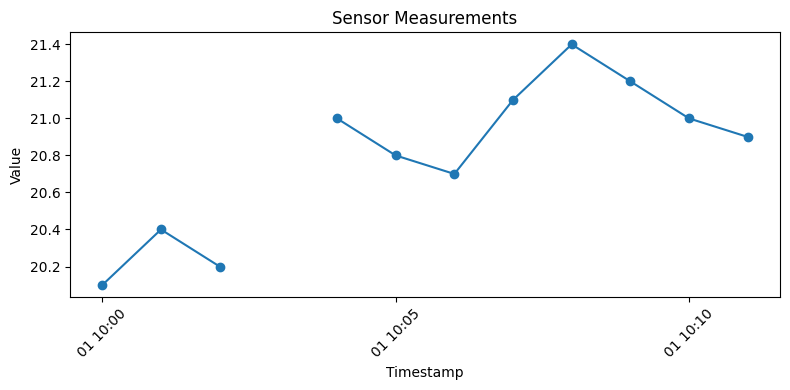

In [17]:
# AI mode: Local tool support for AI as architecture.
df = pd.read_csv(sensor_path)
df["timestamp"] = pd.to_datetime(df["timestamp"])

plt.figure(figsize=(8, 4))
plt.plot(df["timestamp"], df["value"], marker="o")
plt.title("Sensor Measurements")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 18. Add tool output back into the AI workflow

> **AI mode:** AI as architecture.

Now we show a more advanced AI-native pattern:

- the system runs a deterministic tool
- the result becomes context for the LLM
- the Reviewer can use actual computed facts

This is the beginning of a proper **agent + tool** design.

In [18]:
# AI mode: AI as architecture.
TOOL_AWARE_REVIEWER_SYSTEM_PROMPT = """
You are a technical reviewer in an AI-native workflow.
You review generated code using both the original assignment and actual tool output.
Use the tool output as ground truth when possible.
Return a concise markdown review.
""".strip()


def tool_aware_review(assignment: str, generated_solution: str, tool_output: Dict[str, Any]) -> str:
    prompt = f"""
Original assignment:
{assignment}

Generated solution:
{generated_solution}

Actual tool output from sample CSV analysis:
{json.dumps(tool_output, indent=2)}

Review the solution. Does it handle the actual data characteristics? What should be improved?
"""
    return call_ollama(prompt, system=TOOL_AWARE_REVIEWER_SYSTEM_PROMPT, temperature=0.1)

if OLLAMA_AVAILABLE:
    tool_review = tool_aware_review(result.assignment, result.generated_solution, analysis)
else:
    tool_review = "Ollama not available."

print(tool_review)

**Code Review**

The generated code attempts to read sensor measurements from a CSV file, compute statistics (average and standard deviation), and generate a simple plot using matplotlib. However, there are some issues with handling the actual data characteristics.

**Issues:**

1. **Incorrect computation of average and standard deviation**: The `compute_statistics` function incorrectly computes the average and standard deviation by calling `mean()` and `std()` on the entire DataFrame instead of just the 'sensor_measurement' column.
2. **Plotting incorrect values**: In the `generate_plot` function, the code plots the computed average and standard deviation as horizontal lines using `plt.axhline`. However, it uses the wrong values for these lines (it should use the actual average and standard deviation from the tool output).
3. **Lack of error handling for plot generation**: The code catches exceptions when generating the plot but does not provide any meaningful feedback or alternative 

## 19. Reflection: chatbot vs service vs architecture

> **AI mode:** Reflection comparing AI as chatbot, AI as service, and AI as architecture.

| Stage | What AI is | What we implemented |
|---|---|---|
| AI as chatbot | conversational interface | one prompt, one answer |
| AI as service | callable capability | notebook calls Ollama API |
| AI as architecture | orchestrated workflow | planner → builder → reviewer + tool output |

> We move from asking the model for an answer to designing a system around model-supported reasoning, tools, and workflows.

## 20. Hands-on exercise for participants

> **AI mode:** Hands-on practice with AI as architecture.

Change the assignment below and rerun the workflow.

Suggested alternatives:

1. Build a Python script that reads energy consumption data and detects anomalies.
2. Build a small command-line tool that converts temperature readings between Celsius and Fahrenheit.
3. Build a Python program that reads network latency measurements and creates a report.
4. Build a function that validates student grades from a CSV file and reports invalid entries.

In [19]:
# AI mode: Hands-on practice with AI as architecture.
participant_assignment = """
Build a Python program that reads network latency measurements from a CSV file,
computes minimum, maximum, average latency, detects values above 100 ms,
and generates a short markdown report.
""".strip()

print(participant_assignment)

Build a Python program that reads network latency measurements from a CSV file,
computes minimum, maximum, average latency, detects values above 100 ms,
and generates a short markdown report.


In [20]:
# AI mode: Hands-on practice with AI as architecture.
# Uncomment to run the participant exercise.
# participant_result = run_ai_native_workflow(participant_assignment)
# print(participant_result.plan)
# print(participant_result.generated_solution)
# print(participant_result.review)

## 21. Optional extension ideas

> **AI mode:** Extension ideas for AI as architecture.

After the workshop, this notebook can be extended into a real project:

- Convert the workflow into a Python package
- Add a Streamlit or FastAPI web UI
- Add file upload
- Add a RAG knowledge layer
- Add structured JSON outputs
- Add persistent memory
- Add a Docker Compose stack with Ollama, Open WebUI, and an agent backend
- Replace simple functions with LangGraph or CrewAI

## 22. Workshop closing message

> **AI mode:** Closing reflection for all three modes.

> AI-native development is not about adding AI at the end.  
> It is about designing software around reasoning, context, tools, workflows, and human oversight from the beginning.

In this notebook, we used a small example to demonstrate that shift in practice.